In [ ]:
!pip install yolov8  # Make sure this reflects the actual package name and version


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/yolo_detection_trash/archive (1).zip'

Streaming output truncated to the last 5000 lines.
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000124.txt  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000124.xml  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000126.jpg  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000126.txt  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000126.xml  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000128.jpg  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000128.txt  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000128.xml  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000130.jpg  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000130.txt  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000130.xml  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000132.jpg  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000132.txt  
  inflating: trash_ICRA19/dataset/train/obj1617_frame0000132.xml  
  inflating

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd

In [ ]:
dataset_path = '/content/trash_ICRA19/dataset/train'
image_files = [os.path.join(dataset_path, file) for file in os.listdir(dataset_path) if file.endswith('.jpg')]
class_names = {0: 'plastic', 1: 'bio', 2: 'rov'}
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]  # Different colors for each class
colors_normalized = [(r / 255, g / 255, b / 255) for (r, g, b) in colors]

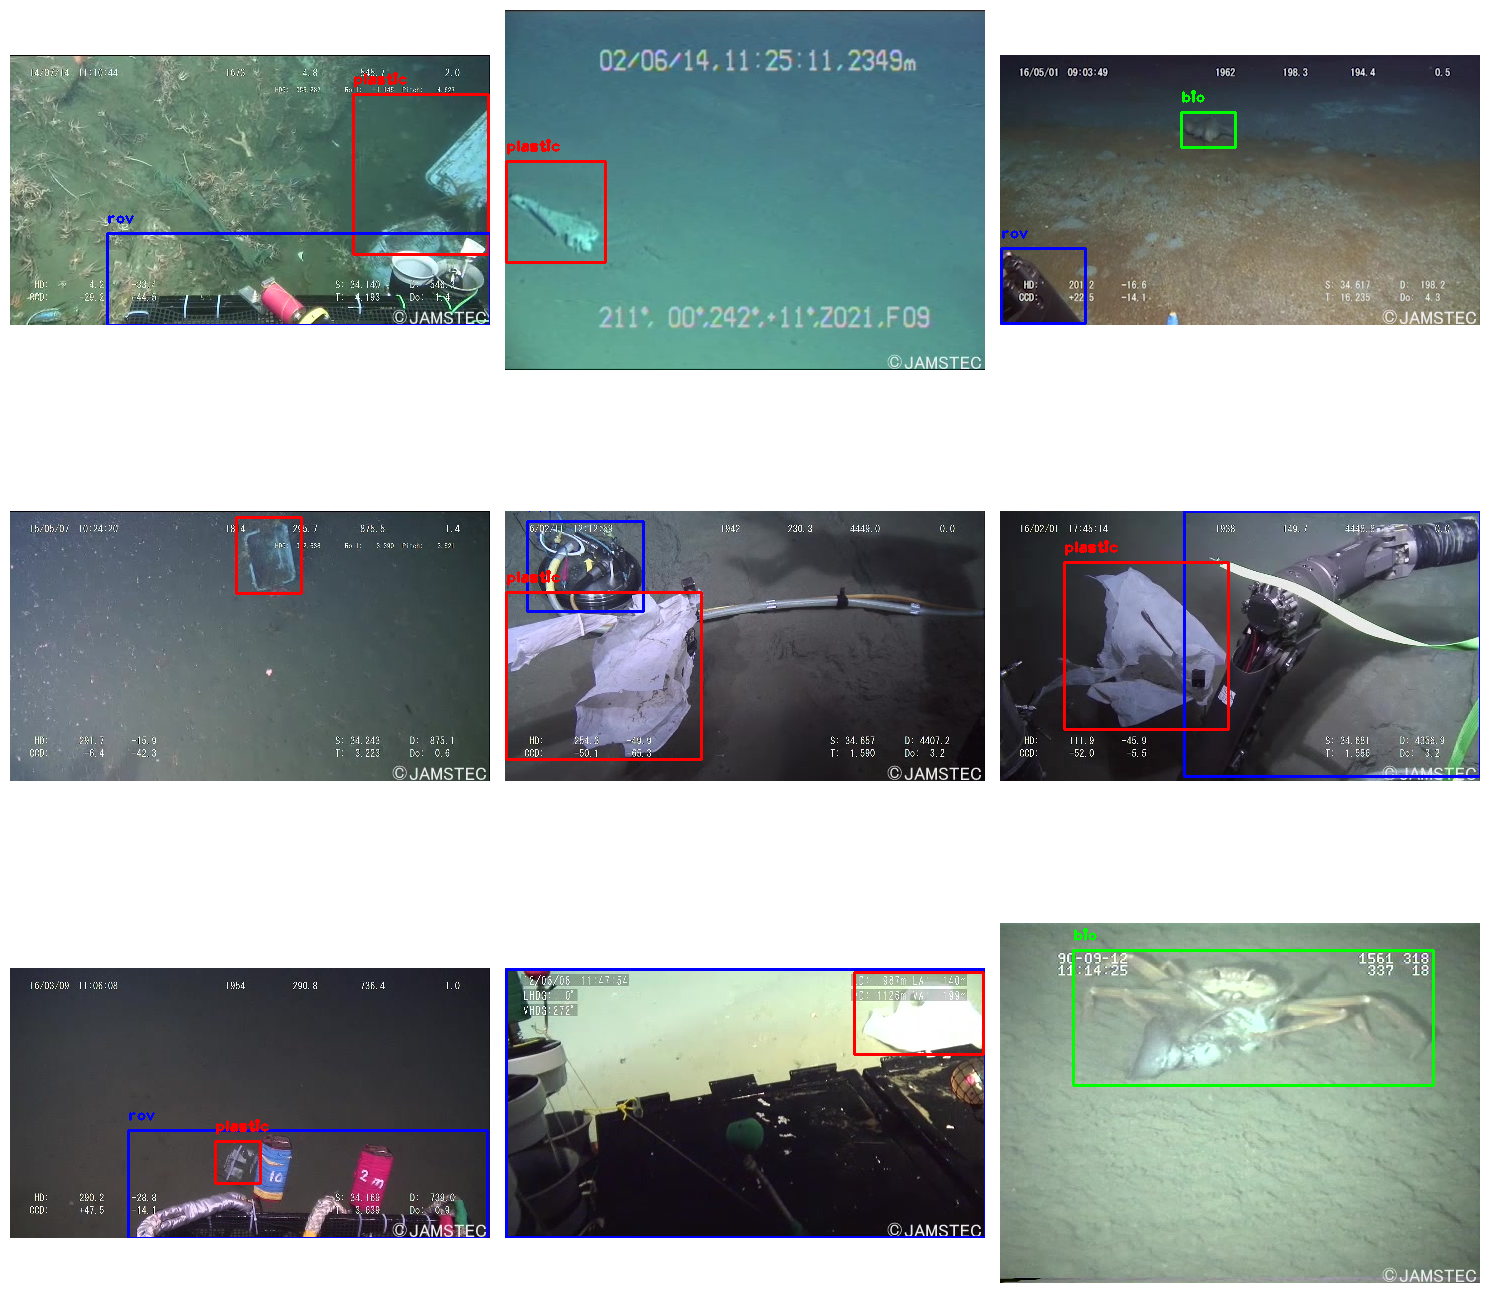

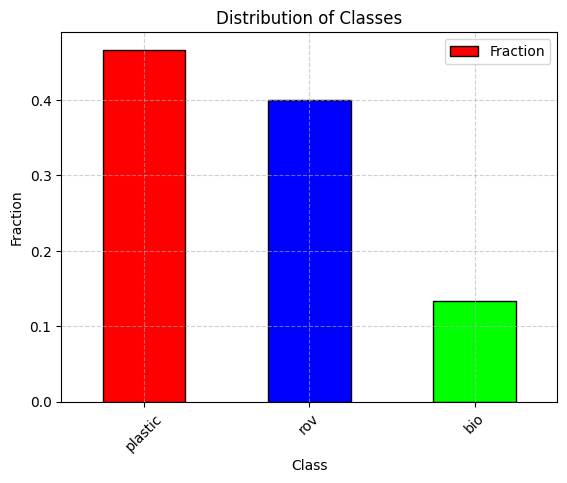

In [ ]:
  # Function to display images with annotations
  def display_images(image_files, num_images=9):
      fig, axs = plt.subplots(3, 3, figsize=(15, 15))
      class_counts = {}

      for i, img_path in enumerate(random.sample(image_files, num_images)):
          # Corresponding annotation file
          txt_path = img_path.replace('.jpg', '.txt')

          # Read image
          image = cv2.imread(img_path)
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

          # Read annotations
          with open(txt_path, 'r') as file:
              data = file.readlines()
              for line in data:
                  class_id, x_center, y_center, width, height = map(float, line.split())
                  class_id = int(class_id)
                  class_counts[class_id] = class_counts.get(class_id, 0) + 1

                  # Calculate coordinates for cv2.rectangle
                  x_center, y_center, width, height = x_center * image.shape[1], y_center * image.shape[0], width * image.shape[1], height * image.shape[0]
                  x, y = int(x_center - width / 2), int(y_center - height / 2)

                  # Draw rectangle and put class name
                  cv2.rectangle(image, (x, y), (x + int(width), y + int(height)), colors[class_id], 2)
                  cv2.putText(image, class_names[class_id], (x, y - 10), cv2.FONT_HERSHEY_PLAIN, 1, colors[class_id], 2)

          ax = axs[i // 3, i % 3]
          ax.imshow(image)
          ax.axis('off')

      plt.tight_layout()
      plt.show()

      # Display class distribution using normalized colors
      total_counts = sum(class_counts.values())
      class_fractions = {class_names[k]: v / total_counts for k, v in class_counts.items()}
      df = pd.DataFrame(list(class_fractions.items()), columns=['Class', 'Fraction'])
      df.plot(kind='bar', x='Class', y='Fraction', color=[colors_normalized[x] for x in class_counts.keys()], edgecolor='black')
      plt.title('Distribution of Classes')
      plt.ylabel('Fraction')
      plt.grid(True, linestyle='--', alpha=0.6)
      plt.xticks(rotation=45)
      plt.show()

  display_images(image_files)

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

In [ ]:
model = YOLO("yolov8x.pt")
dict_classes = model.model.names

100%|██████████| 131M/131M [00:01<00:00, 130MB/s]


In [ ]:
print(len(model.names))

80


In [ ]:
model.train(data='/content/trash_ICRA19/config.yaml', epochs=10, batch=16)

Ultralytics YOLOv8.2.78 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8x.pt, data=/content/trash_ICRA19/config.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tru

100%|██████████| 755k/755k [00:00<00:00, 22.3MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1      2320  ultralytics.nn.modules.conv.Conv             [3, 80, 3, 2]                 
  1                  -1  1    115520  ultralytics.nn.modules.conv.Conv             [80, 160, 3, 2]               
  2                  -1  3    436800  ultralytics.nn.modules.block.C2f             [160, 160, 3, True]           
  3                  -1  1    461440  ultralytics.nn.modules.conv.Conv             [160, 320, 3, 2]              
  4                  -1  6   3281920  ultralytics.nn.modules.block.C2f             [320, 320, 6, True]           
  5                  -1  1   1844480  ultralytics.nn.modules.conv.Conv             [320, 640, 3, 2]              
  6                  -1  6  13117440  ultralytics.nn.modules.block.C2f             [640, 640, 6, True]           
  7                  -1  1   3687680  ultralytics

100%|██████████| 6.25M/6.25M [00:00<00:00, 102MB/s]


AMP: checks passed ✅


...

                   all        820       1064      0.371      0.532      0.389      0.251



10 epochs completed in 1.287 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 136.7MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 136.7MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics YOLOv8.2.78 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 268 layers, 68,126,457 parameters, 0 gradients, 257.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:20<00:00,  1.30it/s]


                   all        820       1064      0.372      0.533      0.389       0.25
               plastic        819        853      0.682      0.874      0.868      0.619
                   bio         54         70      0.124      0.214     0.0618     0.0306
                   rov        141        141       0.31      0.511      0.239      0.102
Speed: 0.2ms preprocess, 17.3ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd2e554fcd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
import shutil
from google.colab import files

# Path to the directory you want to download
directory_path = '/content/runs'

# Path to the zip file
zip_path = '/content/drive/MyDrive/yolo_detection_trash/runs_trash_under_water.zip'

# Zip the directory
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', directory_path)

# Download the zip file
files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

# Attempt to set the locale (this typically won't work on Colab as it requires system privileges)
os.environ['LC_ALL'] = 'en_US.UTF-8'
os.environ['LANG'] = 'en_US.UTF-8'


In [ ]:
import pip

try:
    pip.main(['install', 'supervision'])  # This is just an example and likely won't work because 'supervision' doesn't exist.
except Exception as e:
    print("An error occurred:", e)


Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Collecting supervision

Using cached supervision-0.22.0-py3-none-any.whl.metadata (13 kB)

Requirement already satisfied: defusedxml<0.8.0,>=0.7.1 in /usr/local/lib/python3.10/dist-packages (from supervision) (0.7.1)

Requirement already satisfied: matplotlib>=3.6.0 in /usr/local/lib/python3.10/dist-packages (from supervision) (3.7.1)

...

Requirement already satisfied: python-dateutil>=2.7 in /usr/local/lib/python3.10/dist-packages (from matplotlib>=3.6.0->supervision) (2.8.2)

Requirement already satisfied: six>=1.5 in /usr/local/lib/python3.10/dist-packages (from python-dateutil>=2.7->matplotlib>=3.6.0->supervision) (1.16.0)

Using cached supervision-0.22.0-py3-none-any.whl (135 kB)

Installing collected packages: supervision

Successfully installed supervision-0.22.0

In [ ]:
# Run this cell in your Google Colab notebook
!pip install torch torchvision


NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968

In [ ]:
!yolo task=detect mode=predict source="/content/trash_ICRA19/videos_for_testing/bali.mp4" model=/content/runs/detect/train2/weights/best.pt show=True

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()

Ultralytics YOLOv8.2.78 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 268 layers, 68,126,457 parameters, 0 gradients, 257.4 GFLOPs

video 1/1 (frame 1/4615) /content/trash_ICRA19/videos_for_testing/bali.mp4: 384x640 (no detections), 71.8ms
video 1/1 (frame 2/4615) /content/trash_ICRA19/videos_for_testing/bali.mp4: 384x640 (no detections), 52.6ms
video 1/1 (frame 3/4615) /content/trash_ICRA19/videos_for_testing/bali.mp4: 384x640 (no detections), 52.5ms
video 1/1 (frame 4/4615) /content/trash_ICRA19/videos_for_testing/bali.mp4: 384x640 1 rov, 52.2ms
video 1/1 (frame 5/4615) /content/trash_ICRA19/videos_for_testing/bali.mp4: 384x640 1 rov, 32.5ms
video 1/1 (frame 6/4615) /content/trash_ICRA19/videos_for_testing/bali.mp4: 384x640 1 rov, 32.0ms
video 1/1 (frame 7/4615) /content/trash_ICRA19/videos_for_testing/bali.mp4: 384x640 1 rov, 33.1ms
video 1/1 (frame 8/4615) /content/tras

In [ ]:
import supervision as sv
import numpy as np
from ultralytics import YOLO

VIDEO_PATH = "/content/trash_ICRA19/videos_for_testing/bali.mp4"

model = YOLO("/content/runs/detect/train2/weights/best.pt")

video_info = sv.VideoInfo.from_video_path(VIDEO_PATH)


0: 736x1280 (no detections), 138.6ms
Speed: 4.7ms preprocess, 138.6ms inference, 1.1ms postprocess per image at shape (1, 3, 736, 1280)


AttributeError: type object 'Detections' has no attribute 'from_yolov8'